In [3]:
!unzip archive.zip


Archive:  archive.zip
  inflating: creditcard.csv          


# **Import Required Libraries for Data Analysis and Machine Learning**



In [34]:
# ===============================
# DATASET CONFIGURATION
# ===============================

DATASET_PATH = "/content/creditcard.csv"
TARGET_COLUMN = "Class"

# **Load Credit Card Fraud Dataset Using Pandas**



In [35]:
import pandas as pd

df = pd.read_csv(DATASET_PATH)
df.shape
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df["Class"].value_counts()
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


# **Display First Rows of Dataset to Understand Data Structure**

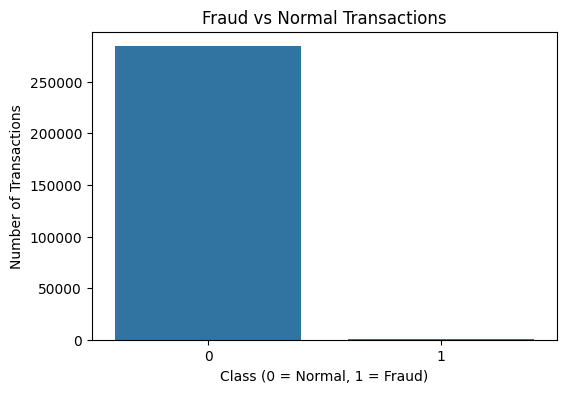

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

# **Analyze Class Distribution to Detect Dataset Imbalance**

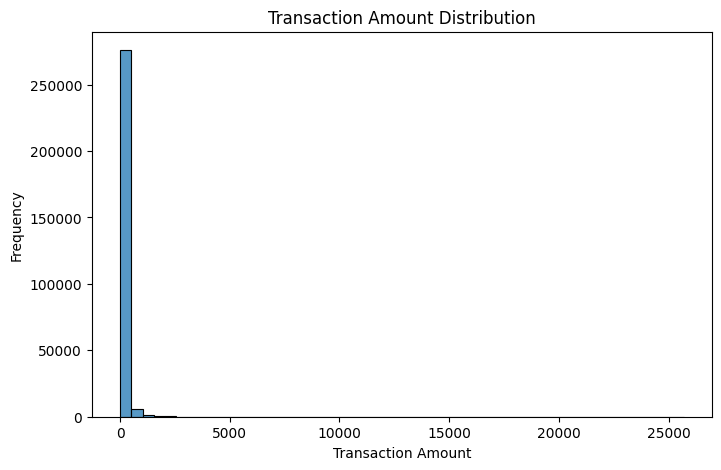

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Amount", bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

# **Visualize Fraud vs Normal Transaction Distribution**

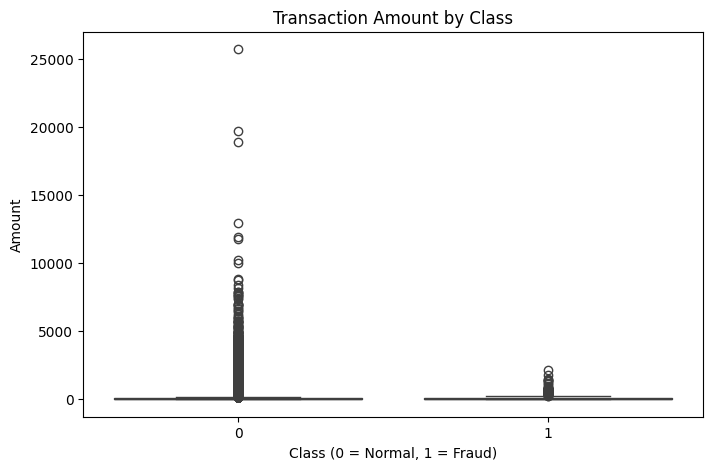

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount")

plt.show()

# **Split Dataset into Features (X) and Target Variable (y)**

In [36]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# **Divide Dataset into Training and Testing Sets**

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# **Apply Feature Scaling Using StandardScaler**

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Train Logistic Regression Model for Fraud Detection**

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

# **Generate Predictions on Test Dataset**

In [18]:
y_pred = model.predict(X_test)

# **Evaluate Logistic Regression Model Using Classification Report**

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.56      0.67        98

    accuracy                           1.00     56962
   macro avg       0.92      0.78      0.84     56962
weighted avg       1.00      1.00      1.00     56962



# **Handle Imbalanced Dataset Using Random Undersampling**

In [20]:
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

normal_sample = normal.sample(len(fraud), random_state=42)

balanced_df = pd.concat([fraud, normal_sample])

# **Create Balanced Dataset for Model Training**

In [21]:
balanced_df["Class"].value_counts()

,count
Class,
1,492
0,492


# **Create Balanced Dataset for Model Training**

In [22]:
X_bal = balanced_df.drop("Class", axis=1)
y_bal = balanced_df["Class"]

# **Split Balanced Dataset into Training and Testing Sets**

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bal,
    y_bal,
    test_size=0.2,
    random_state=42
)

# **Apply Feature Scaling on Balanced Dataset**

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Evaluate Model Performance After Balancing Dataset**

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

# **Visualize Model Performance Using Confusion Matrix**

In [26]:
y_pred = model.predict(X_test)

# **Visualize Model Performance Using Confusion Matrix**

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        98
           1       1.00      0.91      0.95        99

    accuracy                           0.95       197
   macro avg       0.96      0.95      0.95       197
weighted avg       0.96      0.95      0.95       197



# **Train Random Forest Classifier for Fraud Detection**

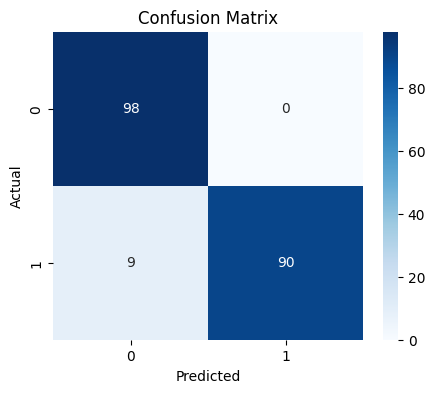

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# **Evaluate Random Forest Model Performance**

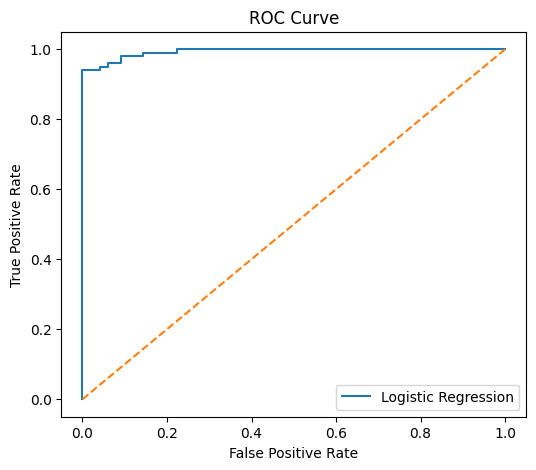

AUC Score: 0.9934034219748505


In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
y_pred_rf = rf.predict(X_test)

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        98
           1       0.99      0.91      0.95        99

    accuracy                           0.95       197
   macro avg       0.95      0.95      0.95       197
weighted avg       0.95      0.95      0.95       197



# **Visualize Top Features Influencing Fraud Detection**

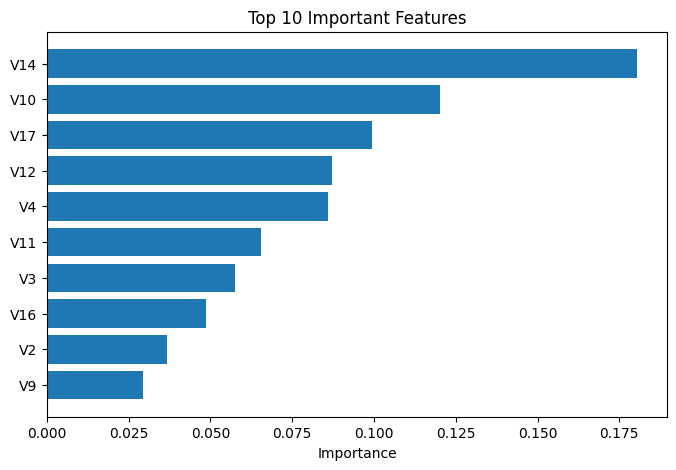

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()